# LISA Channel-Pair Sensitivity Diagnostics

This notebook extends the existing `felix/notebook_code.py` Figure 9 reproduction without changing it. It adds five diagnostics around the same sensitivity and SNR machinery:

1. channel-pair sensitivity curves for `AA`, `EE`, `TT`, `AE`, `AT`, `ET`,
2. inverse-variance fractional channel weights,
3. cumulative SNR as a function of the upper frequency cutoff,
4. low-frequency response scaling checks,
5. an explicit even/odd parity comparison.

All displayed sensitivity curves keep the same plotting convention as the current Figure 9 reproduction, i.e. the shown quantity is $\Omega^{\ell}_{{\rm GW},n}(f)\,h^2 / \sqrt{4\pi}$. Internally, the SNR and weighting calculations still use the raw Eq. (4.43) sensitivities. For the cross pairs, a multiplicity factor of 2 is included so that the six independent pairs reproduce the original ordered-pair inverse-variance combination exactly. The optimally combined curve is plotted separately from the channel-pair panels so the per-pair structure is easier to compare across multipoles.


In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from matplotlib.ticker import LogLocator, LogFormatterMathtext

felix_dir = Path.cwd()
if not (felix_dir / 'notebook_code.py').exists():
    felix_dir = Path.cwd() / 'felix'
if str(felix_dir) not in sys.path:
    sys.path.insert(0, str(felix_dir))

import notebook_code as nb

CHANNEL_PAIRS = ['AA', 'EE', 'TT', 'AE', 'AT', 'ET']
PAIR_MULTIPLICITY = {'AA': 1.0, 'EE': 1.0, 'TT': 1.0, 'AE': 2.0, 'AT': 2.0, 'ET': 2.0}
PAIR_GROUPS = {
    'AA': ['AA'],
    'EE': ['EE'],
    'TT': ['TT'],
    'AE': ['AE', 'EA'],
    'AT': ['AT', 'TA'],
    'ET': ['ET', 'TE'],
}
PAIR_COLORS = {
    'AA': '#1f77b4',
    'EE': '#ff7f0e',
    'TT': '#2ca02c',
    'AE': '#d62728',
    'AT': '#9467bd',
    'ET': '#8c564b',
    'combined': 'black',
}

REPRESENTATIVE_ELLS = [1, 2, 3, 4]
SCALING_PAIR_BY_ELL = {1: 'AE', 2: 'AA', 3: 'AE', 4: 'AA'}

# Start with these settings for interactive work; increase NSIDE and NFREQ for final export.
LMAX = 10
NSIDE = 32
ITER_SHT = 1
NFREQ = 120
FREQ = np.logspace(-4.5, -0.35, NFREQ)

T_OBS_YR = 4.0
OMEGA_GW_H2 = lambda f: nb.power_law_omega_gw_h2(f, amplitude_h2=1.0e-12, alpha=0.0, f_ref=1.0e-3)
C_ELL_GW = np.ones(LMAX + 1)
LOW_FREQ_MAX = 2.0e-3

In [2]:
def _cumtrapz(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(y, dtype=float)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * np.diff(x))
    return out


def _symmetrize_ordered_pair_dict(pair_dict):
    unique = {}
    for pair, ordered_names in PAIR_GROUPS.items():
        stacked = np.stack([np.asarray(pair_dict[name], dtype=float) for name in ordered_names], axis=0)
        unique[pair] = np.mean(stacked, axis=0)
    return unique


def combine_unique_pair_omegas(pair_omega_unique):
    template = np.asarray(next(iter(pair_omega_unique.values())), dtype=float)
    inv2 = np.zeros_like(template, dtype=float)
    for pair in CHANNEL_PAIRS:
        omega = np.asarray(pair_omega_unique[pair], dtype=float)
        mask = np.isfinite(omega) & (omega > 0.0)
        inv2[mask] += PAIR_MULTIPLICITY[pair] / omega[mask]**2
    out = np.full_like(inv2, np.inf, dtype=float)
    good = inv2 > 0.0
    out[good] = 1.0 / np.sqrt(inv2[good])
    return out


def compute_pair_weights(pair_omega_unique):
    template = np.asarray(next(iter(pair_omega_unique.values())), dtype=float)
    total_inv2 = np.zeros_like(template, dtype=float)
    numerators = {}
    for pair in CHANNEL_PAIRS:
        omega = np.asarray(pair_omega_unique[pair], dtype=float)
        numer = np.zeros_like(template, dtype=float)
        mask = np.isfinite(omega) & (omega > 0.0)
        numer[mask] = PAIR_MULTIPLICITY[pair] / omega[mask]**2
        numerators[pair] = numer
        total_inv2 += numer
    weights = {}
    good = total_inv2 > 0.0
    for pair in CHANNEL_PAIRS:
        weight = np.zeros_like(template, dtype=float)
        weight[good] = numerators[pair][good] / total_inv2[good]
        weights[pair] = weight
    return weights


def compute_weight_normalization_error(pair_weight_dict):
    total = np.zeros_like(np.asarray(next(iter(pair_weight_dict.values())), dtype=float))
    for pair in CHANNEL_PAIRS:
        total += np.asarray(pair_weight_dict[pair], dtype=float)
    return float(np.max(np.abs(total - 1.0)))


def fit_loglog_slope(f, y, fmax):
    mask = (f <= fmax) & np.isfinite(y) & (y > 0.0)
    if np.count_nonzero(mask) < 3:
        return np.nan, np.nan, mask
    slope, intercept = np.polyfit(np.log10(f[mask]), np.log10(y[mask]), 1)
    return slope, intercept, mask


def ell_linestyle(ell):
    return '-' if ell % 2 == 0 else '--'


def pair_linestyle(ell, pair):
    auto_pair = pair in ['AA', 'EE', 'TT']
    return '--' if (ell % 2 == 1 and auto_pair) else '-'


def set_axes_style(ax, ylabel=None, xlabel='Frequency [Hz]', xlog=True, ylog=True):
    if xlog:
        ax.set_xscale('log')
        ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
        ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))
    if ylog:
        ax.set_yscale('log')
        ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
    ax.grid(True, which='both', linestyle=':')
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if xlabel is not None:
        ax.set_xlabel(xlabel)


def set_weight_axes_style(ax, ylabel=None, xlabel='Frequency [Hz]'):
    set_axes_style(ax, ylabel=ylabel, xlabel=xlabel, xlog=True, ylog=False)
    ax.set_ylim(-0.02, 1.02)
    ax.axhline(0.0, color='0.85', lw=0.8, zorder=0)
    ax.axhline(1.0, color='0.85', lw=0.8, zorder=0)


def compute_lisa_multipole_sensitivity_detailed(f_grid, lmax=10, nside=32, iter_sht=1):
    f_grid = np.asarray(f_grid, float)
    if lmax > 3 * nside - 1:
        raise ValueError(f'HEALPix sampling constraint: need lmax <= 3*nside-1, got lmax={lmax}, nside={nside}')

    L = nb.L_ARM
    r1 = np.array([0.0, 0.0, 0.0])
    r2 = np.array([L, 0.0, 0.0])
    r3 = np.array([0.5 * L, 0.5 * np.sqrt(3.0) * L, 0.0])
    pos = [r1, r2, r3]

    def unit(v):
        return v / np.linalg.norm(v)

    l12 = unit(r2 - r1)
    l13 = unit(r3 - r1)
    l21 = unit(r1 - r2)
    l23 = unit(r3 - r2)
    l31 = unit(r1 - r3)
    l32 = unit(r2 - r3)
    arms_by_sc = {0: (l12, l13), 1: (l23, l21), 2: (l31, l32)}

    pos_sec = [p / nb.C_LIGHT for p in pos]
    delta_sec = np.zeros((3, 3, 3))
    for i in range(3):
        for j in range(3):
            delta_sec[i, j] = pos_sec[i] - pos_sec[j]

    khat, theta, phi = nb.healpix_grid(nside)
    npix = khat.shape[0]
    e_plus, e_cross = nb.polarization_tensors_from_k(khat, theta, phi)

    mu_a = np.empty((3, npix), dtype=np.float64)
    mu_b = np.empty((3, npix), dtype=np.float64)
    gp_a = np.empty((3, npix), dtype=np.float64)
    gx_a = np.empty((3, npix), dtype=np.float64)
    gp_b = np.empty((3, npix), dtype=np.float64)
    gx_b = np.empty((3, npix), dtype=np.float64)

    for i in range(3):
        la, lb = arms_by_sc[i]
        mu_a[i] = khat @ la
        mu_b[i] = khat @ lb
        gp_a[i] = nb.g_pol_from_arm(la, e_plus).real
        gx_a[i] = nb.g_pol_from_arm(la, e_cross).real
        gp_b[i] = nb.g_pol_from_arm(lb, e_plus).real
        gx_b[i] = nb.g_pol_from_arm(lb, e_cross).real

    kdot_delta = np.zeros((3, 3, npix), dtype=np.float64)
    for i in range(3):
        for j in range(3):
            kdot_delta[i, j] = khat @ delta_sec[i, j]
    kdot_flat = kdot_delta.reshape(9, npix)

    ordered_pairs = [(O, Op) for O in nb.O_list for Op in nb.O_list]
    ordered_labels = [f'{O}{Op}' for O, Op in ordered_pairs]
    mix = np.empty((9, 9), dtype=np.float64)
    for pidx, (O, Op) in enumerate(ordered_pairs):
        cO = nb.C_AET[nb.O_idx[O]]
        cOp = nb.C_AET[nb.O_idx[Op]]
        mix[pidx, :] = (cO[:, None] * cOp[None, :]).reshape(9)

    n_a = nb.N_tilde_AE(f_grid)
    n_e = n_a.copy()
    n_t = nb.N_tilde_T(f_grid)
    n_map = {'A': n_a, 'E': n_e, 'T': n_t}

    idx_mpos_by_ell = nb.precompute_alm_indices(lmax)[1]

    raw_total = {ell: np.zeros_like(f_grid) for ell in range(lmax + 1)}
    ordered_pair_omega = {ell: {label: np.zeros_like(f_grid) for label in ordered_labels} for ell in range(lmax + 1)}
    ordered_rtilde = {ell: {label: np.zeros_like(f_grid) for label in ordered_labels} for ell in range(lmax + 1)}

    rplus = np.empty((3, npix), dtype=np.complex128)
    rcross = np.empty((3, npix), dtype=np.complex128)
    pref_rlm = 1.0 / (8.0 * np.pi)

    for fi, f in enumerate(f_grid):
        u = f / nb.F_STAR
        ta_a = nb.T_transfer(u, mu_a)
        ta_b = nb.T_transfer(u, mu_b)

        rplus[:] = gp_a * ta_a - gp_b * ta_b
        rcross[:] = gx_a * ta_a - gx_b * ta_b
        pol_sum = (
            rplus[:, None, :] * np.conj(rplus[None, :, :])
            + rcross[:, None, :] * np.conj(rcross[None, :, :])
        )
        phase_flat = np.exp(-2j * np.pi * f * kdot_flat)
        maps_ij_flat = pref_rlm * pol_sum.reshape(9, npix) * phase_flat
        maps_pair = mix @ maps_ij_flat

        alms_a = []
        alms_c = []
        for pidx in range(9):
            mp = maps_pair[pidx]
            mp_re = mp.real.astype(np.float64, copy=False)
            mp_im = mp.imag.astype(np.float64, copy=False)
            A = hp.map2alm(mp_re, lmax=lmax, iter=iter_sht, pol=False)
            B = hp.map2alm(mp_im, lmax=lmax, iter=iter_sht, pol=False)
            alms_a.append(A + 1j * B)
            alms_c.append(A - 1j * B)

        for ell in range(lmax + 1):
            idx0 = hp.Alm.getidx(lmax, ell, 0)
            idxm = idx_mpos_by_ell[ell]
            rtilde_pairs = np.empty(9, dtype=np.float64)
            for pidx in range(9):
                aa = alms_a[pidx]
                cc = alms_c[pidx]
                power = np.abs(aa[idx0])**2
                if idxm.size > 0:
                    power += np.sum(np.abs(aa[idxm])**2) + np.sum(np.abs(cc[idxm])**2)
                rtilde_pairs[pidx] = np.sqrt(np.pi * power)
            rtilde_pairs = np.maximum(rtilde_pairs, 1e-45)

            omega_pairs = []
            for pidx, (O, Op) in enumerate(ordered_pairs):
                label = ordered_labels[pidx]
                omega = nb.omega_channel_channel(f, rtilde_pairs[pidx], n_map[O][fi], n_map[Op][fi])
                ordered_pair_omega[ell][label][fi] = omega
                ordered_rtilde[ell][label][fi] = rtilde_pairs[pidx]
                omega_pairs.append(omega)
            raw_total[ell][fi] = nb.optimal_omega_from_ordered_pairs(omega_pairs)

    raw_pairs = {ell: _symmetrize_ordered_pair_dict(ordered_pair_omega[ell]) for ell in range(lmax + 1)}
    rtilde_pairs = {ell: _symmetrize_ordered_pair_dict(ordered_rtilde[ell]) for ell in range(lmax + 1)}
    figure9_total = {ell: raw_total[ell] * nb.Y00 for ell in range(lmax + 1)}
    figure9_pairs = {
        ell: {pair: arr * nb.Y00 for pair, arr in raw_pairs[ell].items()}
        for ell in range(lmax + 1)
    }
    weights = {ell: compute_pair_weights(raw_pairs[ell]) for ell in range(lmax + 1)}
    weight_normalization_err = {
        ell: compute_weight_normalization_error(weights[ell])
        for ell in range(lmax + 1)
    }
    auto_weight = {
        ell: weights[ell]['AA'] + weights[ell]['EE'] + weights[ell]['TT']
        for ell in range(lmax + 1)
    }
    cross_weight = {
        ell: weights[ell]['AE'] + weights[ell]['AT'] + weights[ell]['ET']
        for ell in range(lmax + 1)
    }
    recombined_raw = {ell: combine_unique_pair_omegas(raw_pairs[ell]) for ell in range(lmax + 1)}
    recombination_relerr = {}
    for ell in range(lmax + 1):
        denom = np.maximum(raw_total[ell], 1e-300)
        recombination_relerr[ell] = np.max(np.abs(recombined_raw[ell] - raw_total[ell]) / denom)

    return {
        'raw_total': raw_total,
        'figure9_total': figure9_total,
        'raw_pairs': raw_pairs,
        'figure9_pairs': figure9_pairs,
        'rtilde_pairs': rtilde_pairs,
        'weights': weights,
        'weight_normalization_err': weight_normalization_err,
        'auto_weight': auto_weight,
        'cross_weight': cross_weight,
        'recombination_relerr': recombination_relerr,
    }


def compute_cumulative_snr(f_grid, raw_sensitivity_by_ell, omega_gw_h2, c_ell_gw=None, t_obs_yr=4.0, fmin=None, fmax=None):
    snr_results = nb.compute_snr_per_multipole_eq444(
        f_grid=f_grid,
        raw_sensitivity_by_ell=raw_sensitivity_by_ell,
        omega_gw_h2=omega_gw_h2,
        c_ell_gw=c_ell_gw,
        t_obs_yr=t_obs_yr,
        fmin=fmin,
        fmax=fmax,
    )
    t_obs_sec = float(t_obs_yr * 365.25 * 24.0 * 3600.0)
    cumulative_snr2 = {}
    cumulative_snr = {}
    cumulative_frac = {}
    for ell in snr_results['ells']:
        values = t_obs_sec * _cumtrapz(snr_results['integrands'][ell], f_grid)
        values = np.maximum(values, 0.0)
        cumulative_snr2[ell] = values
        cumulative_snr[ell] = np.sqrt(values)
        cumulative_frac[ell] = values / values[-1] if values[-1] > 0.0 else np.zeros_like(values)
    return snr_results, cumulative_snr2, cumulative_snr, cumulative_frac


Maximum relative difference between the original ordered-pair combination and the six-pair recombination:
  ell=1: 3.045e-16
  ell=2: 3.201e-16
  ell=3: 2.984e-16
  ell=4: 4.476e-16

Maximum absolute deviation from sum_p w_p = 1:
  ell=1: 2.220e-16
  ell=2: 3.331e-16
  ell=3: 2.220e-16
  ell=4: 4.441e-16

Odd-multipole auto-channel weight maxima (parity consistency check):
  ell=1: max w_auto = 9.029e-08
  ell=3: max w_auto = 1.006e-11


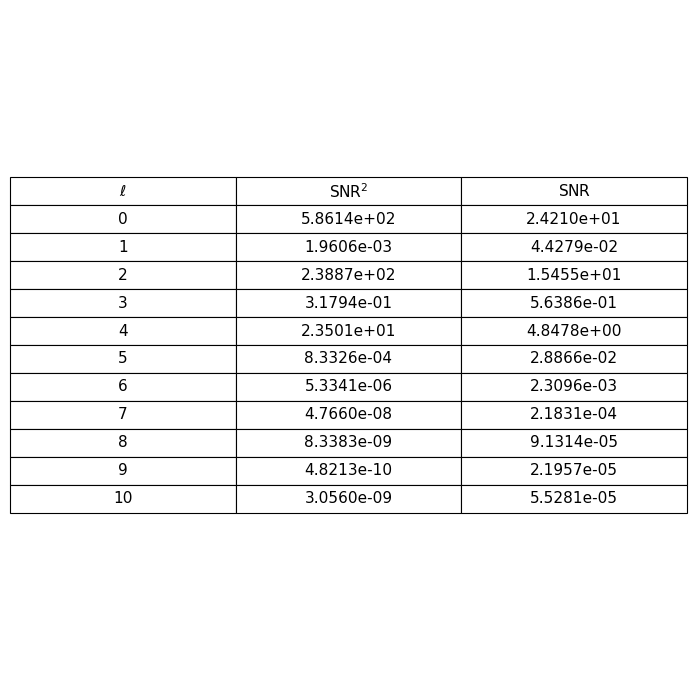

In [3]:
detailed = compute_lisa_multipole_sensitivity_detailed(
    FREQ,
    lmax=LMAX,
    nside=NSIDE,
    iter_sht=ITER_SHT,
)

snr_results, cumulative_snr2, cumulative_snr, cumulative_frac = compute_cumulative_snr(
    FREQ,
    detailed['raw_total'],
    omega_gw_h2=OMEGA_GW_H2,
    c_ell_gw=C_ELL_GW,
    t_obs_yr=T_OBS_YR,
)

print('Maximum relative difference between the original ordered-pair combination and the six-pair recombination:')
for ell in REPRESENTATIVE_ELLS:
    print(f"  ell={ell}: {detailed['recombination_relerr'][ell]:.3e}")

print('\nMaximum absolute deviation from sum_p w_p = 1:')
for ell in REPRESENTATIVE_ELLS:
    print(f"  ell={ell}: {detailed['weight_normalization_err'][ell]:.3e}")

print('\nOdd-multipole auto-channel weight maxima (parity consistency check):')
for ell in [ell for ell in REPRESENTATIVE_ELLS if ell % 2 == 1]:
    print(f"  ell={ell}: max w_auto = {np.max(detailed['auto_weight'][ell]):.3e}")

nb.show_snr_table(snr_results)


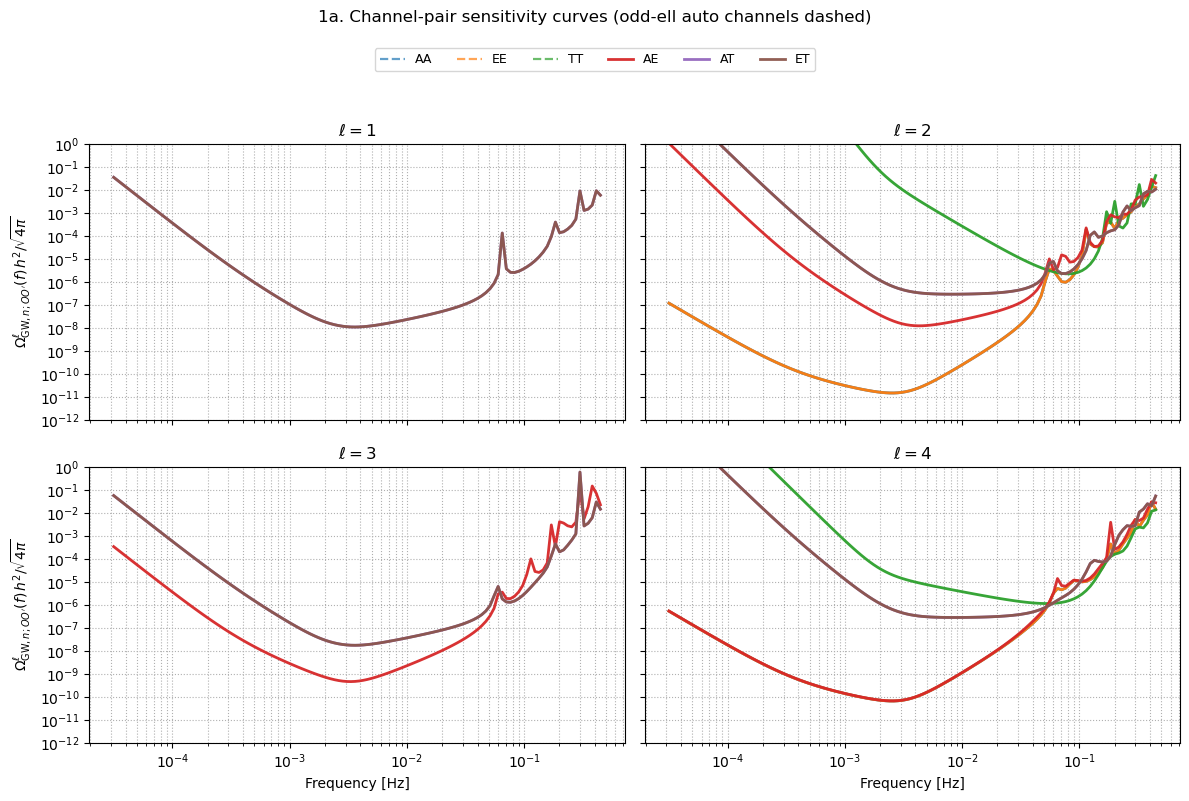

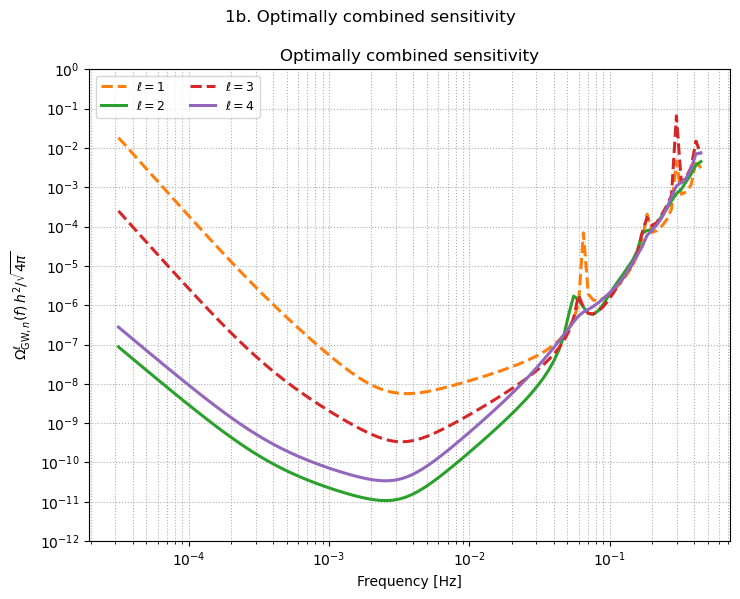

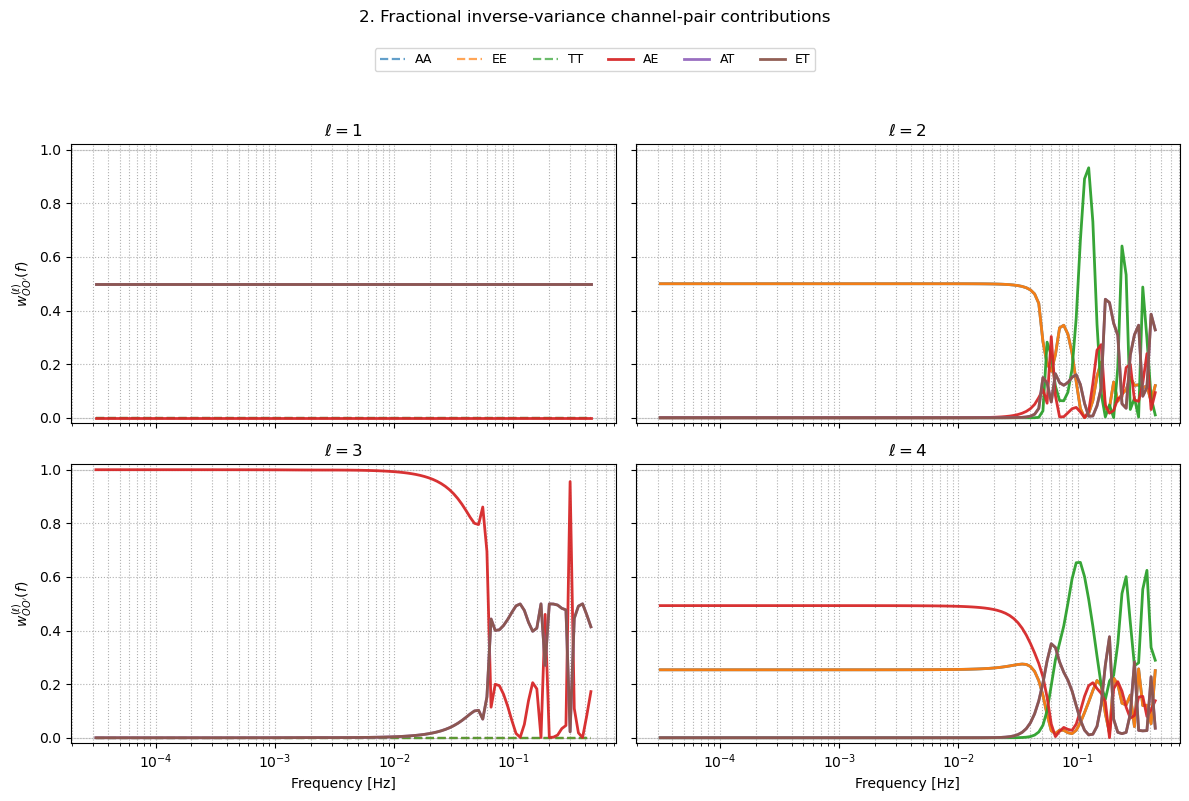

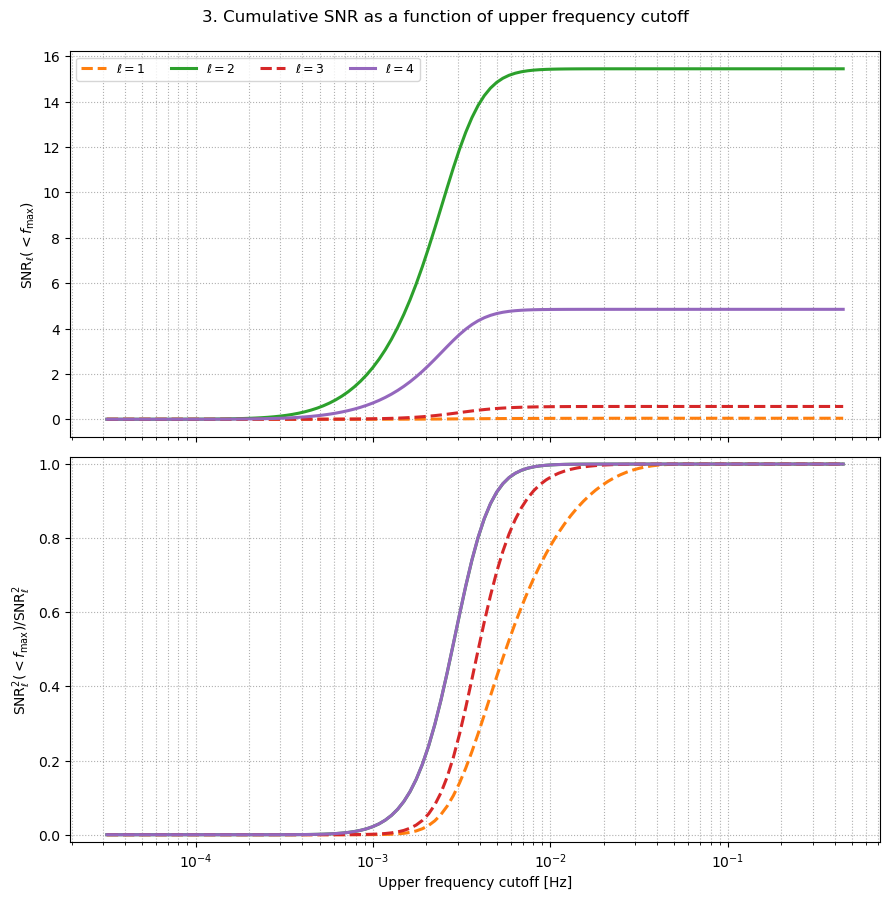

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, ell in zip(axes.flat, REPRESENTATIVE_ELLS):
    for pair in CHANNEL_PAIRS:
        ls = pair_linestyle(ell, pair)
        ax.loglog(
            FREQ,
            detailed['figure9_pairs'][ell][pair],
            color=PAIR_COLORS[pair],
            lw=2.0 if ls == '-' else 1.6,
            ls=ls,
            alpha=0.95 if ls == '-' else 0.70,
            label=pair,
        )
    set_axes_style(
        ax,
        ylabel=r"$\Omega_{{\rm GW},n;OO'}^{\ell}(f)\,h^2 / \sqrt{4\pi}$" if ax in [axes[0, 0], axes[1, 0]] else None,
        xlabel='Frequency [Hz]' if ax in [axes[1, 0], axes[1, 1]] else None,
    )
    ax.set_ylim(1e-12, 1e0)
    ax.set_title(rf"$\ell={ell}$")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=6, loc='upper center', bbox_to_anchor=(0.5, 0.955), fontsize=9)
fig.suptitle('1a. Channel-pair sensitivity curves (odd-ell auto channels dashed)', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 6))
for ell in REPRESENTATIVE_ELLS:
    ax.loglog(
        FREQ,
        detailed['figure9_total'][ell],
        color=f'C{ell}',
        lw=2.2,
        ls=ell_linestyle(ell),
        label=rf"$\ell={ell}$",
    )
set_axes_style(
    ax,
    ylabel=r"$\Omega_{{\rm GW},n}^{\ell}(f)\,h^2 / \sqrt{4\pi}$",
    xlabel='Frequency [Hz]',
)
ax.set_ylim(1e-12, 1e0)
ax.set_title('Optimally combined sensitivity')
ax.legend(ncol=2, fontsize=9)
fig.suptitle('1b. Optimally combined sensitivity', y=0.99)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, ell in zip(axes.flat, REPRESENTATIVE_ELLS):
    for pair in CHANNEL_PAIRS:
        ls = pair_linestyle(ell, pair)
        ax.semilogx(
            FREQ,
            detailed['weights'][ell][pair],
            color=PAIR_COLORS[pair],
            lw=2.0 if ls == '-' else 1.6,
            ls=ls,
            alpha=0.95 if ls == '-' else 0.70,
            label=pair,
        )
    set_weight_axes_style(
        ax,
        ylabel=r"$w_{OO'}^{(\ell)}(f)$" if ax in [axes[0, 0], axes[1, 0]] else None,
        xlabel='Frequency [Hz]' if ax in [axes[1, 0], axes[1, 1]] else None,
    )
    ax.set_title(rf"$\ell={ell}$")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=6, loc='upper center', bbox_to_anchor=(0.5, 0.955), fontsize=9)
fig.suptitle('2. Fractional inverse-variance channel-pair contributions', y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)
for ell in REPRESENTATIVE_ELLS:
    color = f'C{ell}'
    axes[0].semilogx(FREQ, cumulative_snr[ell], color=color, lw=2.2, ls=ell_linestyle(ell), label=rf"$\ell={ell}$")
    axes[1].semilogx(FREQ, cumulative_frac[ell], color=color, lw=2.2, ls=ell_linestyle(ell), label=rf"$\ell={ell}$")

axes[0].grid(True, which='both', linestyle=':')
axes[1].grid(True, which='both', linestyle=':')
axes[0].xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
axes[1].xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
axes[0].xaxis.set_major_formatter(LogFormatterMathtext(base=10))
axes[1].xaxis.set_major_formatter(LogFormatterMathtext(base=10))
axes[0].set_ylabel(r"$\mathrm{SNR}_{\ell}(<f_{\max})$")
axes[1].set_ylabel(r"$\mathrm{SNR}_{\ell}^2(<f_{\max}) / \mathrm{SNR}_{\ell}^2$")
axes[1].set_xlabel('Upper frequency cutoff [Hz]')
axes[1].set_ylim(-0.02, 1.02)
axes[0].legend(ncol=4, fontsize=9)
fig.suptitle('3. Cumulative SNR as a function of upper frequency cutoff', y=0.995)
plt.tight_layout()
plt.show()


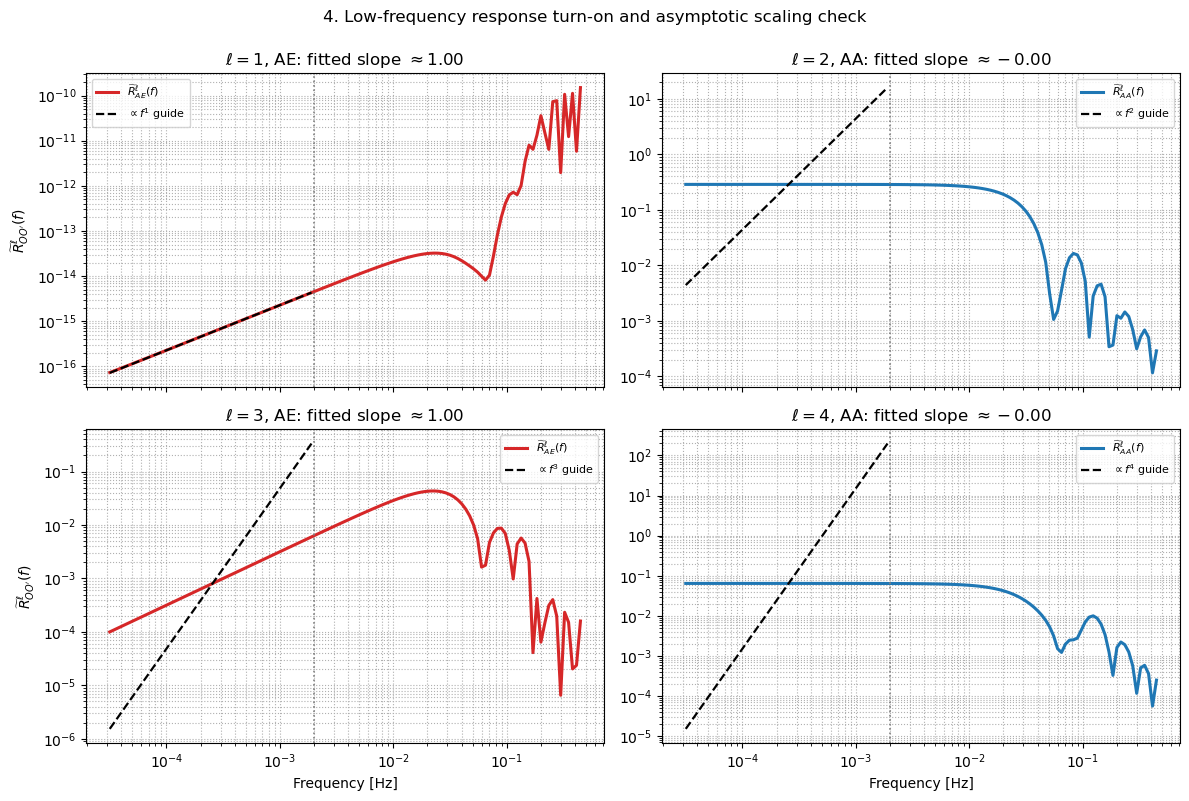

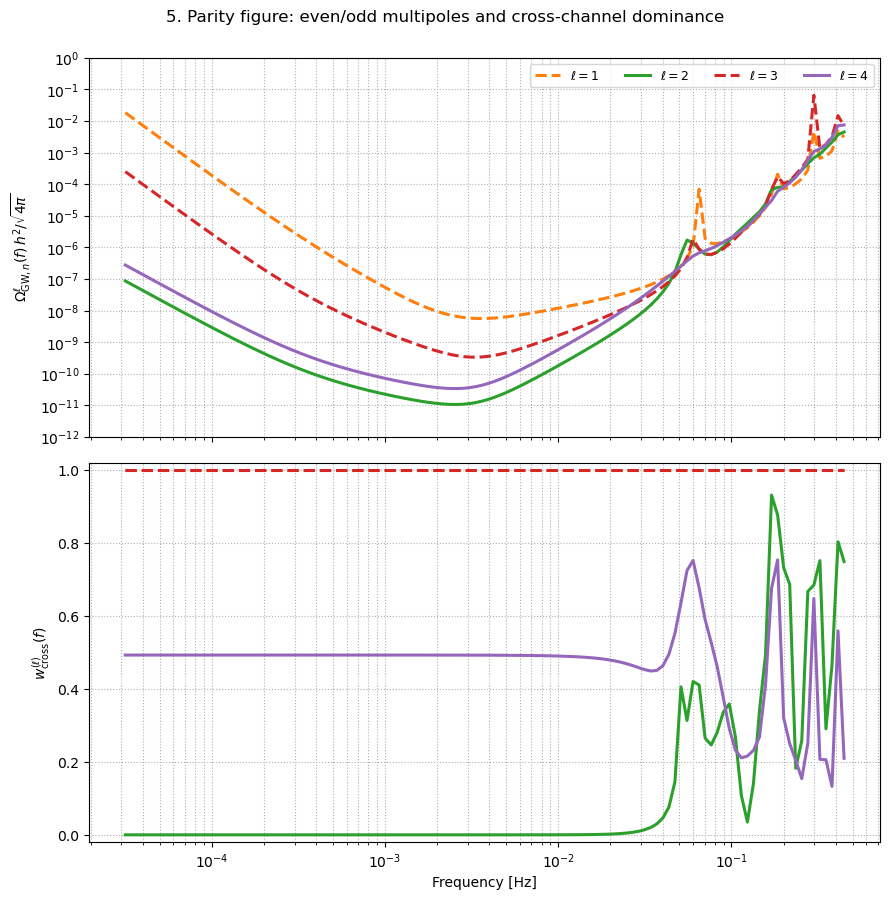

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, ell in zip(axes.flat, REPRESENTATIVE_ELLS):
    pair = SCALING_PAIR_BY_ELL[ell]
    response = detailed['rtilde_pairs'][ell][pair]
    slope, intercept, mask = fit_loglog_slope(FREQ, response, LOW_FREQ_MAX)

    ax.loglog(FREQ, response, color=PAIR_COLORS[pair], lw=2.2, label=rf"$\widetilde{{R}}_{{{pair}}}^{{\ell}}(f)$")
    if np.count_nonzero(mask) >= 3:
        ref_idx = np.where(mask)[0][np.count_nonzero(mask) // 2]
        guide = response[ref_idx] * (FREQ[mask] / FREQ[ref_idx])**ell
        ax.loglog(FREQ[mask], guide, color='black', lw=1.6, ls='--', label=rf"$\propto f^{{{ell}}}$ guide")
    ax.axvline(LOW_FREQ_MAX, color='0.5', ls=':', lw=1.2)
    set_axes_style(
        ax,
        ylabel=r"$\widetilde{R}_{OO'}^{\ell}(f)$" if ax in [axes[0, 0], axes[1, 0]] else None,
        xlabel='Frequency [Hz]' if ax in [axes[1, 0], axes[1, 1]] else None,
    )
    ax.set_title(rf"$\ell={ell}$, {pair}: fitted slope $\approx {slope:.2f}$")
    ax.legend(fontsize=8)

fig.suptitle('4. Low-frequency response turn-on and asymptotic scaling check', y=0.995)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)
for ell in REPRESENTATIVE_ELLS:
    linestyle = '-' if ell % 2 == 0 else '--'
    color = f'C{ell}'
    axes[0].loglog(
        FREQ,
        detailed['figure9_total'][ell],
        color=color,
        lw=2.2,
        ls=linestyle,
        label=rf"$\ell={ell}$",
    )
    axes[1].semilogx(
        FREQ,
        detailed['cross_weight'][ell],
        color=color,
        lw=2.2,
        ls=linestyle,
        label=rf"$\ell={ell}$",
    )

set_axes_style(axes[0], ylabel=r"$\Omega_{{\rm GW},n}^{\ell}(f)\,h^2 / \sqrt{4\pi}$", xlabel=None)
axes[0].set_ylim(1e-12, 1e0)
axes[1].grid(True, which='both', linestyle=':')
axes[1].xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
axes[1].xaxis.set_major_formatter(LogFormatterMathtext(base=10))
axes[1].set_ylabel(r"$w_{\rm cross}^{(\ell)}(f)$")
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_ylim(-0.02, 1.02)
axes[0].legend(ncol=4, fontsize=9)
fig.suptitle('5. Parity figure: even/odd multipoles and cross-channel dominance', y=0.995)
plt.tight_layout()
plt.show()